# Gaussian Mixture Model (GMM) — Basic probabilistic generative model

This notebook demonstrates a simple Gaussian Mixture Model (GMM) as a probabilistic generative model.

- Generate synthetic data from multiple Gaussian components
- Fit a GMM using scikit-learn's `GaussianMixture`
- Inspect learned means/covariances and responsibilities
- Sample from the fitted model and visualize results

Experiment: change `n_components`, `covariance_type`, or dataset to see how model behavior changes.

In [1]:
# Setup: install & imports (will install scikit-learn if missing)
try:
    from sklearn.mixture import GaussianMixture
except Exception:
    import sys
    !{sys.executable} -m pip install -q scikit-learn matplotlib numpy
    from sklearn.mixture import GaussianMixture

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.rcParams.update({"figure.figsize": (7, 5), "font.size": 12})

# small helper to draw covariance ellipses for visualization

def draw_ellipse(ax, mean, cov, color="k", alpha=0.3):
    # cov: 2x2
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    # 2*sqrt(eigvals) gives ~95% ellipse scaling for visualization
    width, height = 2 * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta, color=color, alpha=alpha)
    ax.add_patch(ell)


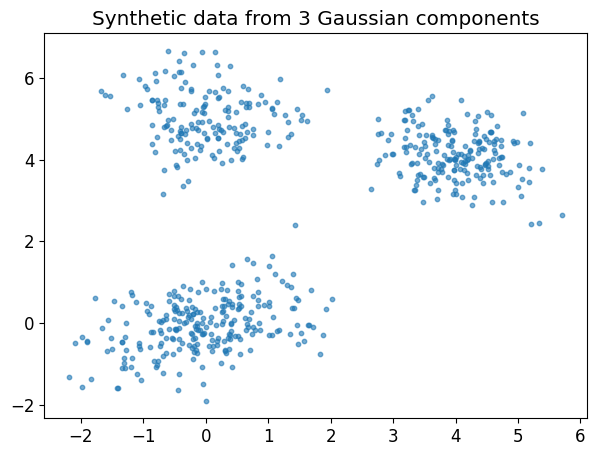

In [2]:
# --- Generate synthetic data ---

def generate_2d_mixture(means, covs, weights, n_samples=500, random_state=None):
    rng = np.random.RandomState(random_state)
    components = rng.choice(len(weights), size=n_samples, p=weights)
    X = np.zeros((n_samples, 2))
    for i, c in enumerate(components):
        X[i] = rng.multivariate_normal(means[c], covs[c])
    return X

# Example mixture
means = [np.array([0, 0]), np.array([4, 4]), np.array([0, 5])]
covs = [np.array([[0.8, 0.3], [0.3, 0.5]]), np.array([[0.5, -0.2], [-0.2, 0.4]]), np.array([[0.4, 0.], [0., 0.4]])]
weights = [0.4, 0.35, 0.25]

X = generate_2d_mixture(means, covs, weights, n_samples=600, random_state=42)

# quick plot
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.6)
plt.title('Synthetic data from 3 Gaussian components')
plt.show()


Learned component weights: [0.406 0.268 0.325]
Learned means:
 [[-0.05  -0.048]
 [ 0.027  5.016]
 [ 4.005  4.103]]
AIC: 3778.306760205238  BIC: 3853.0545643439123


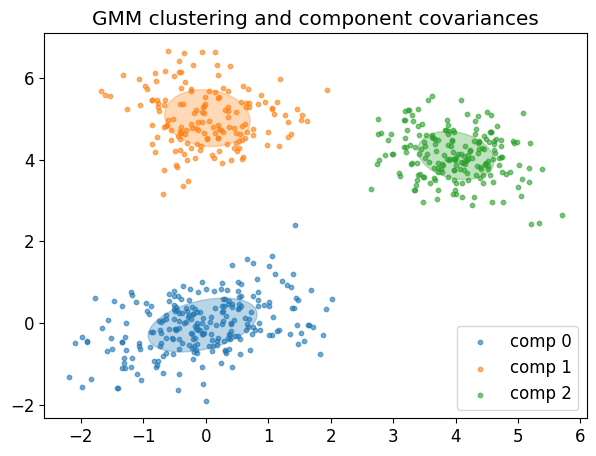

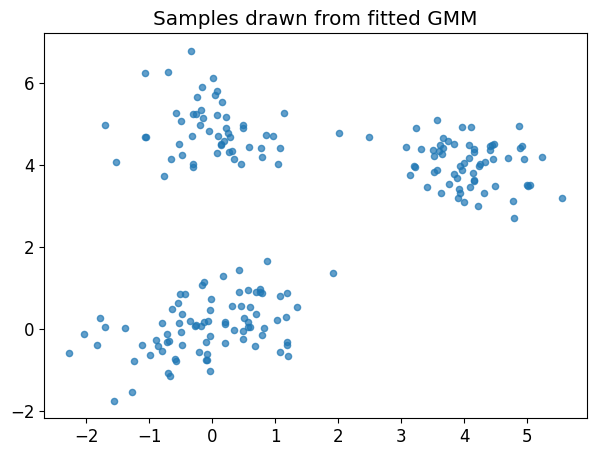

In [3]:
# --- Fit a GMM and visualize results ---

n_components = 3
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=0)
gmm.fit(X)

labels = gmm.predict(X)
probs = gmm.predict_proba(X)

print('Learned component weights:', np.round(gmm.weights_, 3))
print('Learned means:\n', np.round(gmm.means_, 3))
print('AIC:', gmm.aic(X), ' BIC:', gmm.bic(X))

# Plot data colored by predicted component and overlay ellipses for each Gaussian
fig, ax = plt.subplots()
colors = ['C0', 'C1', 'C2', 'C3', 'C4']
for k in range(n_components):
    mask = labels == k
    ax.scatter(X[mask, 0], X[mask, 1], s=10, color=colors[k], alpha=0.6, label=f'comp {k}')
    draw_ellipse(ax, gmm.means_[k], gmm.covariances_[k], color=colors[k])

ax.set_title('GMM clustering and component covariances')
ax.legend()
plt.show()

# Show a sample from the fitted model
samples, comp_idx = gmm.sample(200)
fig, ax = plt.subplots()
ax.scatter(samples[:, 0], samples[:, 1], s=20, alpha=0.7)
ax.set_title('Samples drawn from fitted GMM')
plt.show()


In [4]:
# --- Quick exercises / notes ---

# 1) Try different numbers of components and compare AIC/BIC
for k in range(1,6):
    gm = GaussianMixture(n_components=k, random_state=0).fit(X)
    print(f"k={k}  AIC={gm.aic(X):.1f}  BIC={gm.bic(X):.1f}")

# 2) Inspect responsibilities (soft assignment) for first 5 points
print('\nFirst 5 responsibilities (predict_proba):')
print(np.round(probs[:5], 3))

# 3) Next steps: try diagonal or tied covariances, initialized with KMeans, or implement EM from scratch for learning


k=1  AIC=5178.3  BIC=5200.3
k=2  AIC=4122.7  BIC=4171.0
k=3  AIC=3778.3  BIC=3853.1
k=4  AIC=3769.1  BIC=3870.2
k=5  AIC=3780.5  BIC=3908.0

First 5 responsibilities (predict_proba):
[[1.    0.    0.   ]
 [0.    1.    0.   ]
 [0.    0.    1.   ]
 [0.    0.003 0.997]
 [1.    0.    0.   ]]




A **GMM** is a **probabilistic clustering model**.

* It assumes your data comes from **multiple Gaussian (normal) distributions**
* Each data point belongs to **all clusters with some probability** (not hard labels like K-Means)

---

## What each part of the notebook is doing

### 1️⃣ Title & goal (Markdown cell)

You are supposed to:

* Generate fake data from multiple Gaussians
* Fit a GMM using `sklearn`
* Look at:

  * learned means
  * covariances
  * cluster probabilities (responsibilities)
* Experiment with model settings

👉 This is **concept learning**, not just coding.

---

### 2️⃣ Imports & setup

```python
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
```

* Uses **scikit-learn**’s GMM implementation
* Nothing fancy here

---

### 3️⃣ Data generation

```python
generate_2d_mixture(...)
```

What this function does:

* You define:

  * means (cluster centers)
  * covariances (shape of clusters)
  * weights (how common each cluster is)
* It randomly samples points from these Gaussians

👉 This creates **synthetic 2D data** with known structure
👉 Important because you know the “ground truth”

---

### 4️⃣ Fit the GMM

```python
gmm = GaussianMixture(n_components=3)
gmm.fit(X)
```

This:

* Tries to **recover the hidden Gaussians**
* Learns:

  * `weights_` → how big each cluster is
  * `means_` → cluster centers
  * `covariances_` → cluster shapes

Then:

```python
labels = gmm.predict(X)
probs = gmm.predict_proba(X)
```

* `predict` → hard cluster label
* `predict_proba` → soft assignment (key idea of GMM)

---

### 5️⃣ AIC / BIC experiment (important)

```python
for k in range(1,6):
    gm = GaussianMixture(n_components=k)
    print(AIC, BIC)
```

This answers:

> **How many clusters should I use?**

* **Lower AIC/BIC = better**
* Penalizes overly complex models
* This is how GMMs choose `k` *scientifically*

---

### 6️⃣ Responsibilities

```python
predict_proba(X)
```

This shows:

* Each point belongs **partially** to multiple clusters
* Example: `[0.1, 0.7, 0.2]`

👉 This is the **main difference from K-Means**



## Part 1: AIC / BIC numbers

```
k=1  AIC=5178.3  BIC=5200.3
k=2  AIC=4122.7  BIC=4171.0
k=3  AIC=3778.3  BIC=3853.1
k=4  AIC=3769.1  BIC=3870.2
k=5  AIC=3780.5  BIC=3908.0
```

### What AIC / BIC are

* They measure **model quality**
* **Lower = better**
* They punish models that are too complex

---

### How to read this

Look for the **minimum value**.

#### AIC

* Lowest AIC = **k = 4 (3769.1)**

#### BIC

* Lowest BIC = **k = 3 (3853.1)**

---



* **True number of clusters is likely 3**
* BIC is stricter → prefers simpler model
* AIC allows extra complexity

📌 **In assignments, you usually trust BIC**

So your answer:

> Optimal number of components = **3**

---

## Part 2: Responsibilities (`predict_proba`)

```
[[1.    0.    0.   ]
 [0.    1.    0.   ]
 [0.    0.    1.   ]
 [0.    0.003 0.997]
 [1.    0.    0.   ]]
```

Each row = **one data point**
Each column = **one Gaussian (cluster)**
Each row sums to **1**

---

### Line-by-line meaning

1️⃣ `[1. 0. 0.]`
→ 100% probability cluster 0
→ point is **clearly inside** cluster 0

2️⃣ `[0. 1. 0.]`
→ 100% cluster 1

3️⃣ `[0. 0. 1.]`
→ 100% cluster 2

4️⃣ `[0. 0.003 0.997]`
→ 99.7% cluster 2
→ very close to boundary, but still confident

5️⃣ `[1. 0. 0.]`
→ fully cluster 0

---

### Why this matters

* GMM does **soft clustering**
* Unlike K-Means, points can belong to **multiple clusters**
* Here, your data is well separated → probabilities look “hard”

---

## One-sentence summary

* **AIC/BIC help choose number of clusters; BIC suggests k=3**
* **Responsibilities show probability of each point belonging to each Gaussian**


